<a href="https://colab.research.google.com/github/giovannapessoamelo/ProvaPraticaJulio/blob/main/ProvaJulio.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

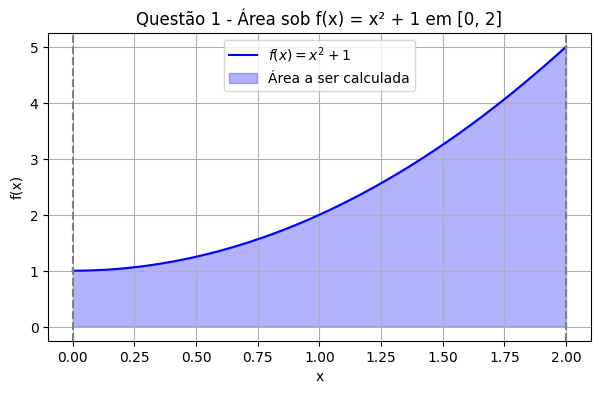

Valor exato (analítico): 14/3 = 4.666667

    n   Esquerda    Direita  Ponto médio  Erro (esq.)
   10   4.280000   5.080000     4.660000     0.386667
   50   4.587200   4.747200     4.666400     0.079467
  100   4.626800   4.706800     4.666600     0.039867
  500   4.658672   4.674672     4.666664     0.007995

Erro absoluto em relação ao valor exato:
  n= 10 | esquerda    : 0.386667
  n= 10 | direita     : 0.413333
  n= 10 | ponto médio : 0.006667
  n= 50 | esquerda    : 0.079467
  n= 50 | direita     : 0.080533
  n= 50 | ponto médio : 0.000267
  n=100 | esquerda    : 0.039867
  n=100 | direita     : 0.040133
  n=100 | ponto médio : 0.000067
  n=500 | esquerda    : 0.007995
  n=500 | direita     : 0.008005
  n=500 | ponto médio : 0.000003


In [1]:
"""
QUESTÃO 1
Considere f(x) = x^2 + 1. Área limitada pelo gráfico de f(x), pelo eixo x
e pelas retas x = 0 e x = 2.
Requisitos: pip install numpy matplotlib
"""

import numpy as np
import matplotlib.pyplot as plt

f = lambda x: x**2 + 1
a, b = 0, 2

# a) Gráfico da função em [0, 2], com a região da área destacada.
x = np.linspace(a, b, 400)
plt.figure(figsize=(7, 4))
plt.plot(x, f(x), color="blue", label=r"$f(x)=x^2+1$")
plt.fill_between(x, f(x), alpha=0.3, color="blue", label="Área a ser calculada")
plt.axvline(a, color="gray", ls="--")
plt.axvline(b, color="gray", ls="--")
plt.title("Questão 1 - Área sob f(x) = x² + 1 em [0, 2]")
plt.xlabel("x"); plt.ylabel("f(x)")
plt.legend(); plt.grid(True)
plt.show()

# b) Aproximação por retângulos (soma de Riemann) com n = 10, 50, 100, 500.
#    Usa extremo esquerdo, extremo direito e ponto médio.
def riemann(f, a, b, n, metodo="esq"):
    h = (b - a) / n
    if metodo == "esq":
        xs = a + h * np.arange(n)
    elif metodo == "dir":
        xs = a + h * np.arange(1, n + 1)
    else:  # ponto médio
        xs = a + h * (np.arange(n) + 0.5)
    return np.sum(f(xs)) * h

# c) Cálculo analítico da integral:
#    ∫_0^2 (x^2 + 1) dx = [x^3/3 + x]_0^2 = 8/3 + 2 = 14/3 ≈ 4,6667
exato = 14 / 3
print(f"Valor exato (analítico): 14/3 = {exato:.6f}\n")

# Tabela com os resultados (item b)
print(f"{'n':>5} {'Esquerda':>10} {'Direita':>10} {'Ponto médio':>12} {'Erro (esq.)':>12}")
for n in [10, 50, 100, 500]:
    e = riemann(f, a, b, n, "esq")
    d = riemann(f, a, b, n, "dir")
    m = riemann(f, a, b, n, "med")
    print(f"{n:>5} {e:>10.6f} {d:>10.6f} {m:>12.6f} {abs(exato - e):>12.6f}")

# d) Comparação do resultado exato com as aproximações numéricas:
#    - A soma à esquerda SUBESTIMA a área (f é crescente em [0, 2]).
#    - A soma à direita SUPERESTIMA a área.
#    - O ponto médio fica bem mais próximo do valor exato.
#    - O erro das somas esquerda/direita é proporcional a 1/n; o do ponto
#      médio é proporcional a 1/n².
print("\nErro absoluto em relação ao valor exato:")
for n in [10, 50, 100, 500]:
    for nome, met in [("esquerda", "esq"), ("direita", "dir"), ("ponto médio", "med")]:
        err = abs(exato - riemann(f, a, b, n, met))
        print(f"  n={n:>3} | {nome:<12}: {err:.6f}")

# e) Por que a aproximação tende ao valor exato quando n aumenta?
#    Com n retângulos, cada um tem largura Δx = (b - a)/n = 2/n. Quanto maior
#    o n, mais estreitos são os retângulos e menor é a diferença entre o topo
#    de cada retângulo e a curva. No limite, a soma de Riemann converge para
#    a integral definida:
#        lim (n→∞) Σ f(x_i) Δx = ∫_0^2 f(x) dx = 14/3


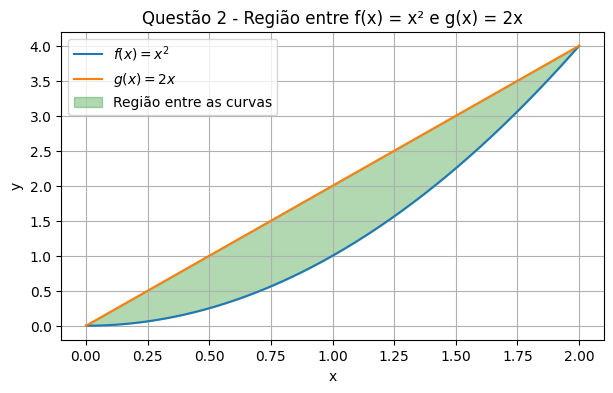

Pontos de interseção (x): [0, 2]
Teste em x=1 -> f(1) = 1 | g(1) = 2 -> g está acima de f
Área numérica (quad): 1.333333
Área analítica (sympy): 4/3 = 1.333333
Diferença |analítico - numérico| = 0.00e+00


In [2]:
"""
QUESTÃO 2
Considere f(x) = x^2 e g(x) = 2x.
Requisitos: pip install numpy matplotlib scipy sympy
"""

import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad
import sympy as sp

f = lambda x: x**2
g = lambda x: 2 * x

# a) Gráfico das funções em [0, 2], destacando a região entre as duas curvas.
x = np.linspace(0, 2, 400)
plt.figure(figsize=(7, 4))
plt.plot(x, f(x), label=r"$f(x)=x^2$")
plt.plot(x, g(x), label=r"$g(x)=2x$")
plt.fill_between(x, f(x), g(x), alpha=0.3, color="green",
                 label="Região entre as curvas")
plt.title("Questão 2 - Região entre f(x) = x² e g(x) = 2x")
plt.xlabel("x"); plt.ylabel("y")
plt.legend(); plt.grid(True)
plt.show()

# b) Pontos de interseção (analiticamente):
#    x^2 = 2x  ->  x^2 - 2x = 0  ->  x(x - 2) = 0  ->  x = 0 ou x = 2
#    Pontos: (0, 0) e (2, 4)
xs = sp.symbols("x")
inter = sp.solve(sp.Eq(xs**2, 2 * xs), xs)
print("Pontos de interseção (x):", inter)

# c) Qual função está acima da outra em [0, 2]?
#    Testando x = 1: f(1) = 1 e g(1) = 2, logo g(x) >= f(x) em [0, 2].
print("Teste em x=1 -> f(1) =", f(1), "| g(1) =", g(1), "-> g está acima de f")

# d) Integral que representa a área entre as curvas:
#        A = ∫_0^2 [g(x) - f(x)] dx = ∫_0^2 (2x - x^2) dx

# e) Cálculo numérico da área com Python.
area_num, _ = quad(lambda t: g(t) - f(t), 0, 2)
print(f"Área numérica (quad): {area_num:.6f}")

# f) Cálculo analítico e comparação com o resultado numérico.
#    A = [x^2 - x^3/3]_0^2 = 4 - 8/3 = 4/3 ≈ 1,3333
area_ana = sp.integrate(2 * xs - xs**2, (xs, 0, 2))
print(f"Área analítica (sympy): {area_ana} = {float(area_ana):.6f}")
print(f"Diferença |analítico - numérico| = {abs(float(area_ana) - area_num):.2e}")
# Os dois valores coincidem (a diferença é só erro de arredondamento).


In [3]:
"""
QUESTÃO 3
Integral I = ∫ x e^x dx
ATENÇÃO: não consegui ler os limites de integração na imagem. Estou
assumindo [0, 1]. Se forem outros, altere apenas a e b abaixo.
Requisitos: pip install numpy scipy sympy
"""

import numpy as np
from scipy.integrate import quad
import sympy as sp

a, b = 0, 1
f = lambda t: t * np.exp(t)

# a) Qual técnica de integração é mais adequada?
#    Integração por partes, pois o integrando é um produto de um polinômio
#    (x) por uma exponencial (e^x).

# b) Justificativa da escolha:
#    Escolhendo u = x e dv = e^x dx, temos du = dx e v = e^x. Assim a nova
#    integral (∫ e^x dx) é mais simples que a original. A substituição
#    simples não funciona, pois a derivada de e^x não aparece multiplicando
#    o integrando de forma útil.

# c) Resolução analítica:
#    ∫ x e^x dx = x e^x - ∫ e^x dx = x e^x - e^x + C = (x - 1) e^x + C
#    Para [0, 1]: [(x - 1) e^x]_0^1 = 0 - (-1) = 1
xs = sp.symbols("x")
primitiva = sp.integrate(xs * sp.exp(xs), xs)
print("Primitiva (sympy):", primitiva)
I_ana = sp.integrate(xs * sp.exp(xs), (xs, a, b))
print(f"Valor analítico: {I_ana} = {float(I_ana):.8f}")

# d) Cálculo numérico com Python.
I_num, erro_est = quad(f, a, b)
print(f"Valor numérico (quad): {I_num:.8f}  (erro estimado: {erro_est:.2e})")

# e) Comparação dos resultados analítico e numérico.
print(f"Diferença |analítico - numérico| = {abs(float(I_ana) - I_num):.2e}")
# Os resultados concordam até a precisão da máquina.

Primitiva (sympy): (x - 1)*exp(x)
Valor analítico: 1 = 1.00000000
Valor numérico (quad): 1.00000000  (erro estimado: 1.11e-14)
Diferença |analítico - numérico| = 0.00e+00


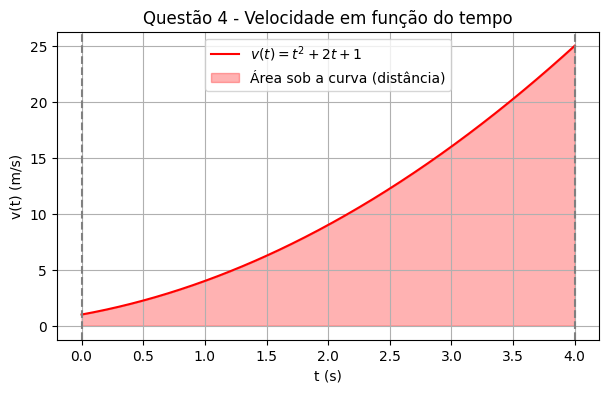

b) Distância numérica (quad): D = 41.333333 m  (erro estimado: 4.59e-13)
c) Distância analítica: D = 124/3 = 41.333333 m
d) Diferença |analítico - numérico| = 7.11e-15 m


In [4]:
"""
QUESTÃO 4
A velocidade de um veículo é modelada por v(t) = t^2 + 2t + 1 (m/s),
para 0 <= t <= 4. A distância percorrida é D = ∫_0^4 v(t) dt.
Requisitos: pip install numpy matplotlib scipy
"""

import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad

v = lambda t: t**2 + 2 * t + 1

# a) Gráfico de v(t) no intervalo [0, 4], destacando a área sob a curva.
t = np.linspace(0, 4, 400)
plt.figure(figsize=(7, 4))
plt.plot(t, v(t), color="red", label=r"$v(t)=t^2+2t+1$")
plt.fill_between(t, v(t), alpha=0.3, color="red",
                 label="Área sob a curva (distância)")
plt.axvline(0, color="gray", ls="--")
plt.axvline(4, color="gray", ls="--")
plt.title("Questão 4 - Velocidade em função do tempo")
plt.xlabel("t (s)"); plt.ylabel("v(t) (m/s)")
plt.legend(); plt.grid(True)
plt.show()

# b) Cálculo numérico da distância percorrida utilizando Python.
D_num, erro_est = quad(v, 0, 4)
print(f"b) Distância numérica (quad): D = {D_num:.6f} m  (erro estimado: {erro_est:.2e})")

# c) Cálculo analítico da distância percorrida:
#    D = ∫_0^4 (t^2 + 2t + 1) dt = [t^3/3 + t^2 + t]_0^4
#      = 64/3 + 16 + 4 = 124/3 ≈ 41,3333 m
D_ana = 124 / 3
print(f"c) Distância analítica: D = 124/3 = {D_ana:.6f} m")

# d) Comparação dos dois resultados:
#    Os valores coincidem: a diferença é apenas erro de arredondamento
#    de ponto flutuante (da ordem de 1e-14), o que confirma o cálculo.
print(f"d) Diferença |analítico - numérico| = {abs(D_ana - D_num):.2e} m")

# e) Interpretação geométrica:
#    Em cada pequeno intervalo de tempo Δt, a distância percorrida é
#    aproximadamente v(t)·Δt, que é a área de um retângulo de altura v(t)
#    e largura Δt. Somando todos esses retângulos, obtém-se uma soma de
#    Riemann; quando Δt tende a zero, ela converge para a integral
#    ∫ v(t) dt, que é exatamente a área sob o gráfico de v(t).
#    Quando v(t) >= 0 (o veículo não anda para trás), todas as áreas são
#    positivas e somam a distância total percorrida. Aqui, v(t) = (t+1)^2 > 0
#    para todo t, então a área sob a curva é a distância percorrida.